<a href="https://colab.research.google.com/github/Adarsh230305/Data_Science/blob/main/Statistics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import seaborn as sn

##Outliers

In [ ]:
arr=np.array([2,4,7,10,15,20,25,205])
arr

array([  2,   4,   7,  10,  15,  20,  25, 205])

<Axes: >

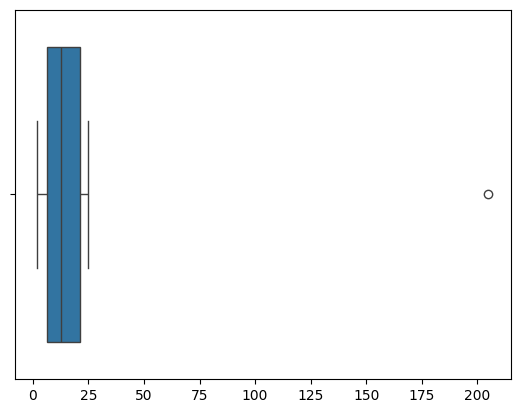

In [ ]:
sn.boxplot(x=arr)

In [ ]:
Q1=np.percentile(arr,25)
Q3=np.percentile(arr,75)
IQR=Q3-Q1
IQR

np.float64(15.0)

In [ ]:
UF=Q3+1.5*IQR
LF=Q1-1.5*IQR

In [ ]:
l=[]
for x in arr:
  if x>=LF and x<=UF:
    l.append(x)
arr2=np.array(l)
arr2

array([ 2,  4,  7, 10, 15, 20, 25])

<Axes: >

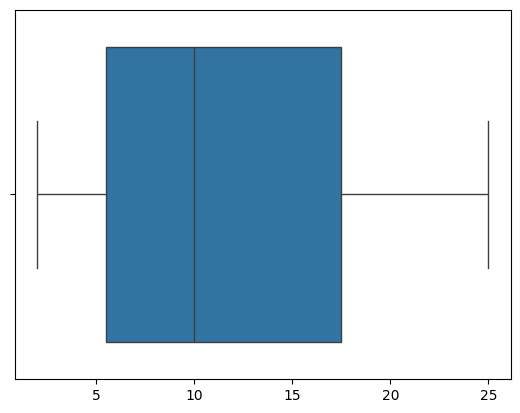

In [ ]:
sn.boxplot(x=arr2) # outlier removed

## Z test

In [ ]:
import numpy as np
from scipy.stats import norm

In [ ]:
data = np.array([
    52, 48, 55, 51, 49,
    53, 47, 50, 54, 52,
    46, 51, 49, 55, 50,
    48, 53, 52, 47, 51,
    54, 49, 50, 52, 56,
    48, 51, 53, 49, 50,
    52, 47, 54, 51, 48
])
sample_mean=np.mean(data)
population_sd=np.sqrt(np.var(data))
population_mean=44
z=np.sqrt(len(data))*(sample_mean-population_mean)/population_sd
z

np.float64(15.68981111429976)

In [ ]:
p_value=2*(1-norm.cdf(abs(z)))
alpha=0.5
if p_value<alpha:
  print("Null hypothesis is rejected")
else:
  print("Null is accepted")

Null hypothesis is rejected


## T-test

In [ ]:
import numpy as np
from scipy import stats

In [ ]:
data = np.array([
    52, 48, 55, 51, 49,
    53, 47, 50, 54, 52,
    46, 51, 49, 55, 50,
    48, 53, 52, 47, 51
])
sample_mean=np.mean(data)
sample_sd=np.std(data,ddof=1)
population_mean=44
n=len(data)
alpha=0.5
t_stats=(sample_mean-population_mean)/(sample_sd/np.sqrt(len(data)))
p_value=2*(1-stats.t.cdf(abs(t_stats),df=n-1))
p_value

np.float64(8.535832041189906e-10)

In [ ]:
if p_value<alpha:
  print("Null hypothesis is rejected")
else:
  print("Null is accepted")

Null hypothesis is rejected


## Two sample

In [ ]:
import numpy as np
from scipy import stats

In [ ]:
group_A = np.array([
    52, 48, 55, 51, 49,
    53, 47, 50, 54, 52
])
group_B = np.array([
    45, 47, 44, 49, 46,
    48, 43, 45, 47, 46
])
t_stats,p_value=stats.ttest_ind(group_A,group_B,equal_var=False)
t_stats,p_value
alpha=0.05

In [ ]:
if p_value<alpha:
  print("Null hypothesis is rejected")
else:
  print("Null is accepted")

Null hypothesis is rejected


## chie square test

In [ ]:
import seaborn as sns
import pandas as pd
from scipy.stats import chi2_contingency

In [ ]:
df=sns.load_dataset('titanic')
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [ ]:
contingency_table=pd.crosstab(df["sex"],df["survived"])
contingency_table

survived,0,1
sex,,
female,81,233
male,468,109


In [ ]:
chi2_value,p_value,dof,expected_value=chi2_contingency(contingency_table)

expected_value

array([[193.47474747, 120.52525253],
       [355.52525253, 221.47474747]])

In [ ]:
alpha=0.05
if p_value<alpha:
  print("Null hypothesis is rejected")
else:
  print("Null is accepted")

Null hypothesis is rejected


## annova test